In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, deconvolve, convolve

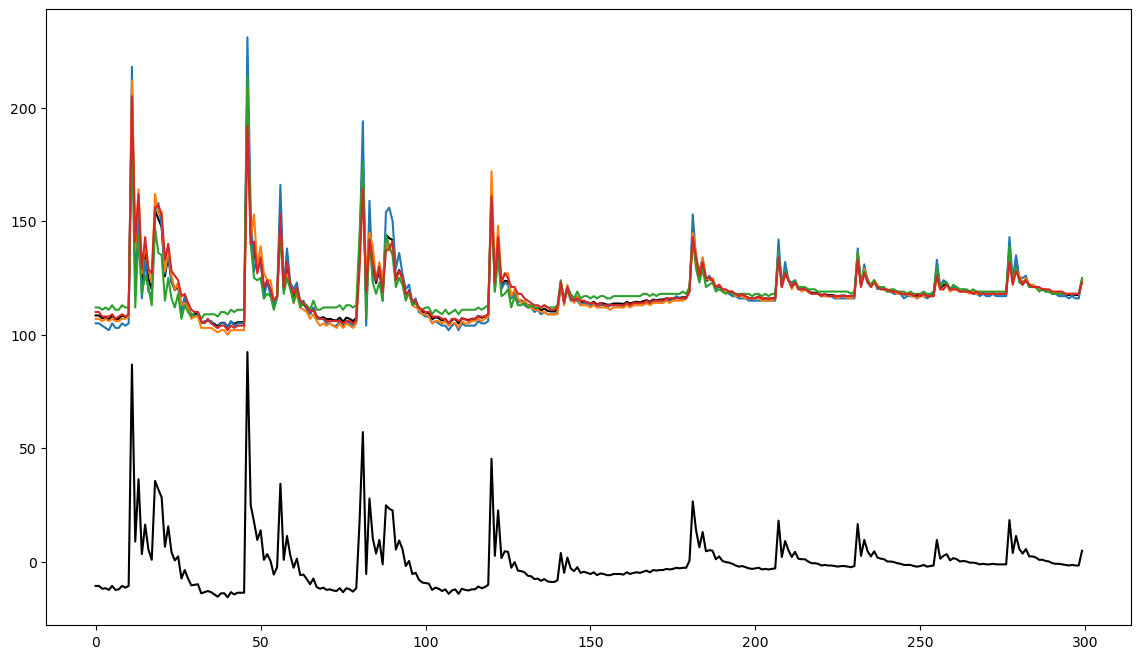

In [46]:
df_iu = pd.read_csv('/home/pico/projects/piezo_data_20250425_140940.csv')
df_iu['sum'] = df_iu['top'] + df_iu['bottom'] + df_iu['left'] + df_iu['right']
df_iu['sum'] = df_iu['sum'] / 4

gmean = df_iu['sum'].values.mean()
fig, ax = plt.subplots(figsize=(14, 8))  # Adjust the size as needed

slice_range = slice(3300, 3600)
ax.plot(df_iu['sum'].values[slice_range], color='black', label='sum')
#ax.plot(df_iu['bottom'].values[4000:4500])
ax.plot( (df_iu['sum'].values - gmean)[slice_range], color='black')
#ax.plot( (df_iu['bottom'].values - gmean)[4000:4500])
ax.plot(df_iu['bottom'].values[slice_range])
ax.plot(df_iu['top'].values[slice_range])
ax.plot(df_iu['left'].values[slice_range])
ax.plot(df_iu['right'].values[slice_range])


In [47]:
df_iu.describe()

,timestamp,top,bottom,left,right,force,sum
count,1.654300e+04,16543.000000,16543.000000,16543.000000,16543.000000,16543.000000,16543.000000
mean,1.006250e+06,118.209454,119.342683,118.497854,120.459711,108.925648,119.127425
std,4.775697e+04,22.902261,24.751970,17.890912,20.483237,33.101413,20.178053
min,9.235400e+05,22.000000,5.000000,55.000000,81.000000,6.000000,79.000000
25%,9.648950e+05,105.000000,106.000000,110.000000,109.000000,110.000000,107.500000
50%,1.006250e+06,114.000000,113.000000,115.000000,116.000000,117.000000,114.250000
75%,1.047605e+06,124.000000,123.000000,120.000000,125.000000,121.000000,122.750000
max,1.088960e+06,255.000000,255.000000,255.000000,255.000000,237.000000,251.000000


Results for top:
Coefficient: 0.8178757822319427
Intercept: -96.6632070063406
R^2 score: 0.8663561652321319



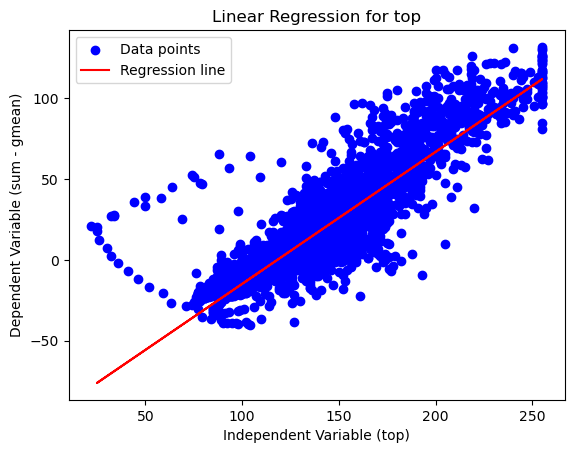

Results for bottom:
Coefficient: 0.7637306497099703
Intercept: -91.18395201088791
R^2 score: 0.8870090830539414



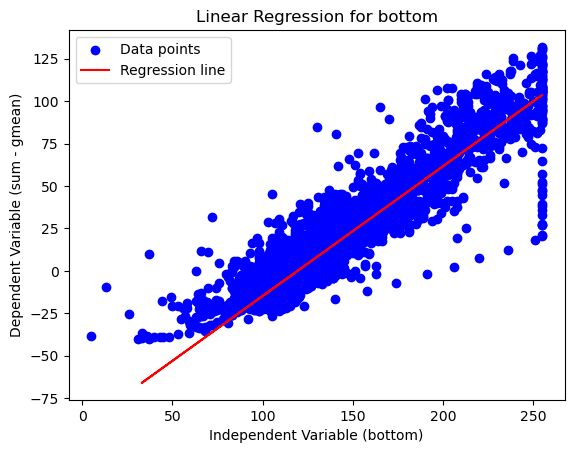

Results for right:
Coefficient: 0.9444750872411163
Intercept: -113.7599322875048
R^2 score: 0.9152637779543245



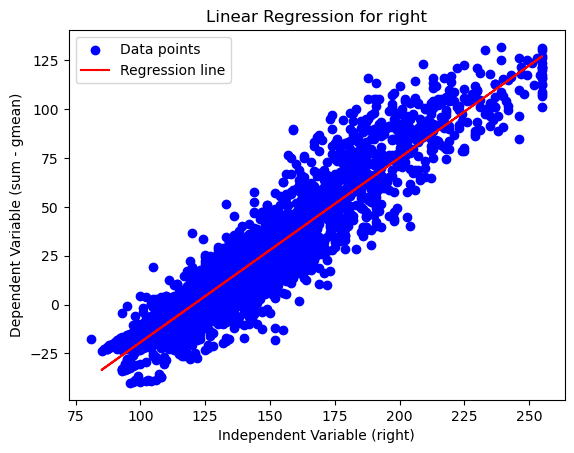

Results for left:
Coefficient: 1.0460837973278967
Intercept: -123.94094600244837
R^2 score: 0.855722012727695



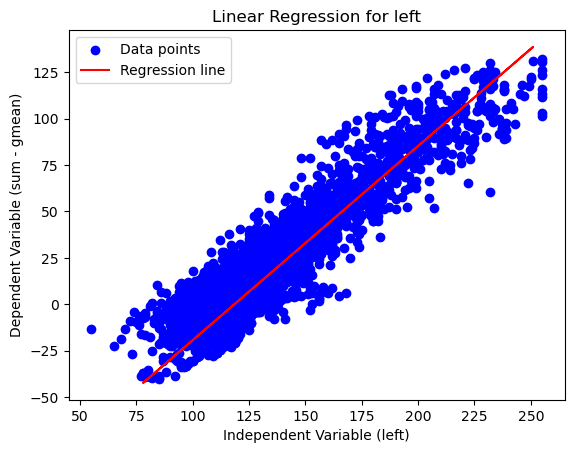

Results for force:
Coefficient: -0.18813997150453307
Intercept: 20.49440673805061
R^2 score: 0.0714534887137922



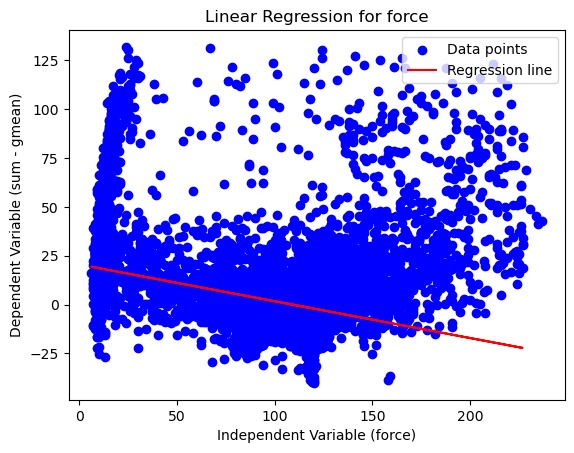

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Assuming df_iu is your DataFrame and gmean is defined
keys = ['top', 'bottom', 'right', 'left', 'force']
results = {}

y = (df_iu['sum'] - gmean).values  # Dependent variable

for key in keys:
    # Prepare the independent variable (X) and dependent variable (y)
    X = (df_iu[key]).values.reshape(-1, 1)  # Reshaped for sklearn
    
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Create a linear regression model
    model = LinearRegression()

    # Fit the model to the training data
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Store the results
    results[key] = {
        'coefficient': model.coef_[0],
        'intercept': model.intercept_,
        'r2_score': model.score(X_test, y_test)
    }

    # Print the coefficients and R^2 score
    print(f"Results for {key}:")
    print("Coefficient:", model.coef_[0])
    print("Intercept:", model.intercept_)
    print("R^2 score:", model.score(X_test, y_test))
    print()

    # Normalize the values and add to DataFrame
    df_iu[f'{key}_norm'] = (df_iu[key]) * model.coef_[0] + model.intercept_

    # Plotting the results
    plt.figure()
    plt.scatter(X, y, color='blue', label='Data points')
    plt.plot(X_test, y_pred, color='red', label='Regression line')
    plt.xlabel(f'Independent Variable ({key})')
    plt.ylabel('Dependent Variable (sum - gmean)')
    plt.title(f'Linear Regression for {key}')
    plt.legend()
    plt.show()

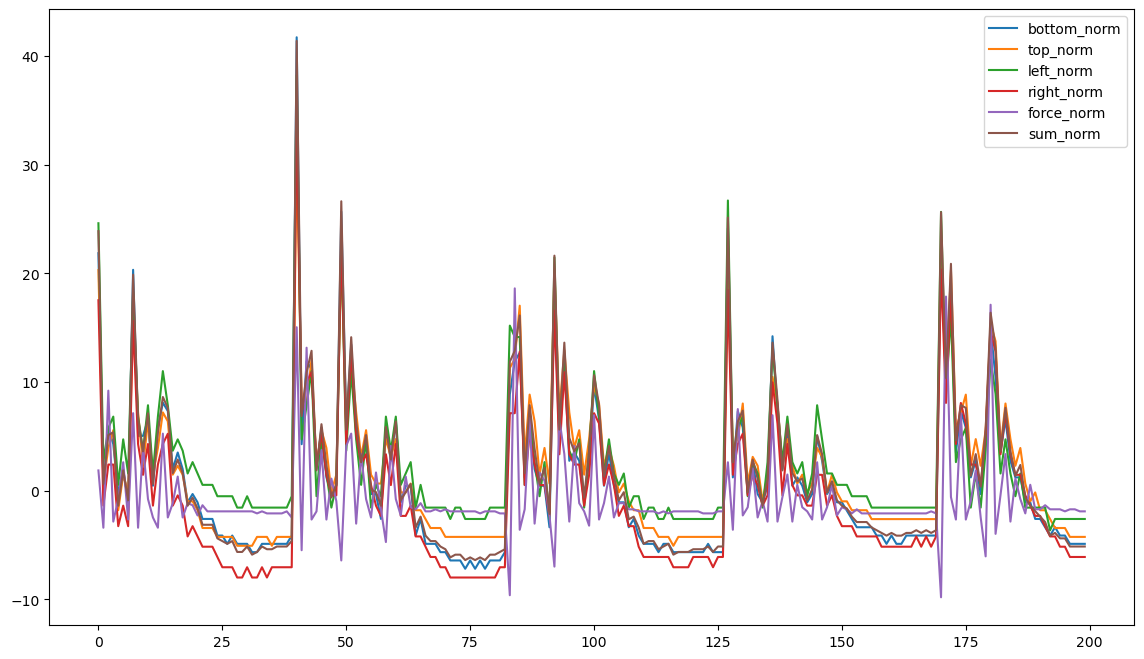

In [72]:
fig, ax = plt.subplots(figsize=(14, 8))  # Adjust the size as needed
slice_range = slice(4000, 4200)
ax.plot(df_iu['bottom_norm'].values[slice_range], label='bottom_norm')
ax.plot(df_iu['top_norm'].values[slice_range], label='top_norm')
ax.plot(df_iu['left_norm'].values[slice_range], label='left_norm')
ax.plot(df_iu['right_norm'].values[slice_range], label='right_norm')
ax.plot(df_iu['force_norm'].values[slice_range], label='force_norm')


ax.plot((df_iu['sum'] - gmean).values[slice_range], label='sum_norm')

ax.legend()  # Show legend


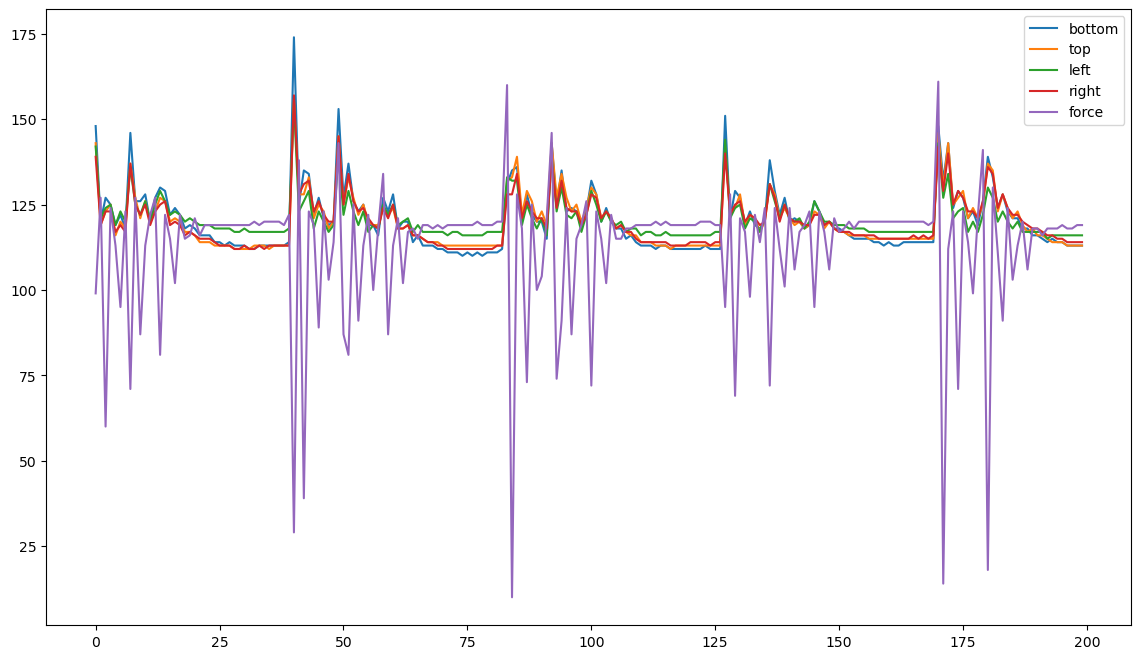

In [76]:
fig, ax = plt.subplots(figsize=(14, 8))  # Adjust the size as needed
slice_range = slice(4000, 4200)
ax.plot(df_iu['bottom'].values[slice_range], label='bottom')
ax.plot(df_iu['top'].values[slice_range], label='top')
ax.plot(df_iu['left'].values[slice_range], label='left')
ax.plot(df_iu['right'].values[slice_range], label='right')
ax.plot(df_iu['force'].values[slice_range], label='force')

ax.legend()  # Show legend

In [51]:
def butter_highpass(cutoff, fs, order=5):
    nyq = 0.5 * fs  # Nyquist frequency
    normal_cutoff = cutoff / nyq  # Normalized cutoff frequency
    b, a = butter(order, normal_cutoff, btype='high', analog=False)  # Filter coefficients
    return b, a

def highpass_filter(data, cutoff, fs, order=5):
    b, a = butter_highpass(cutoff, fs, order=order)  # Get filter coefficients
    y = lfilter(b, a, data)  # Apply the filter
    return y

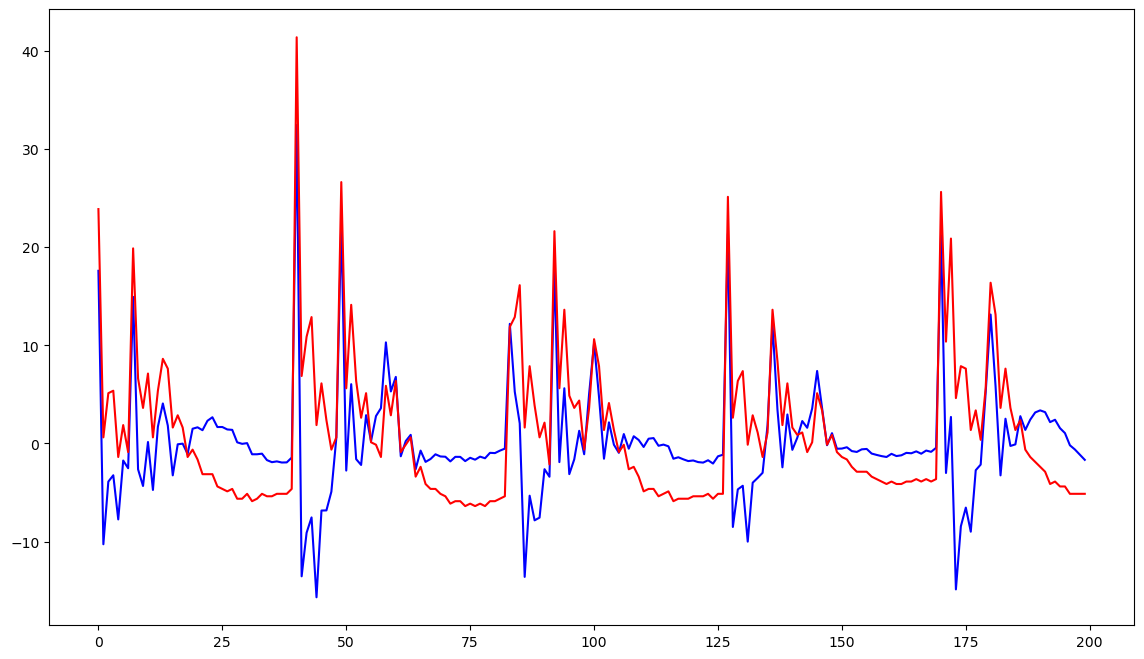

In [53]:
# Create a figure and a set of subplots
fig, ax = plt.subplots(figsize=(14, 8))  # Adjust the size as needed

# Plot each signal on the same axes
l = 'sum'
ax.plot(highpass_filter((df_iu[l]-gmean).values[slice_range], 3, 100), label='Top', color='blue')
ax.plot((df_iu[l]-gmean).values[slice_range], label='Top', color='red')

In [ ]:
df_iu.describe()

,timestamp,top,bottom,left,right,force,sum,top_norm,bottom_norm,right_norm,left_norm,force_norm
count,1.654300e+04,16543.000000,16543.000000,16543.000000,16543.000000,16543.000000,16543.000000,16543.000000,16543.000000,16543.000000,16543.000000,16543.000000
mean,1.006250e+06,118.209454,119.342683,118.497854,120.459711,108.925648,119.127425,0.017443,-0.038287,0.011264,0.017739,0.001138
std,4.775697e+04,22.902261,24.751970,17.890912,20.483237,33.101413,20.178053,18.731205,18.903838,19.345907,18.715393,6.227699
min,9.235400e+05,22.000000,5.000000,55.000000,81.000000,6.000000,79.000000,-78.669940,-87.365299,-37.257450,-66.406337,-24.094767
25%,9.648950e+05,105.000000,106.000000,110.000000,109.000000,110.000000,107.500000,-10.786250,-10.228503,-10.812148,-8.871728,-2.270530
50%,1.006250e+06,114.000000,113.000000,115.000000,116.000000,117.000000,114.250000,-3.425368,-4.882389,-4.200822,-3.641309,-1.517970
75%,1.047605e+06,124.000000,123.000000,120.000000,125.000000,121.000000,122.750000,4.753390,2.754918,4.299454,1.589110,-0.200990
max,1.088960e+06,255.000000,255.000000,255.000000,255.000000,237.000000,251.000000,111.895117,103.567364,127.081215,142.810422,19.365567


In [73]:
df_iu['bottom']

0        119
1        119
2        119
3        119
4        119
        ... 
16538    117
16539    117
16540    117
16541    118
16542    117
Name: bottom, Length: 16543, dtype: int64

In [77]:
df_iu['bottom_clipped'] = df_iu['bottom']
df_iu['bottom_clipped'] = df_iu['bottom_clipped'].clip(lower=0)
# do the same for top, left , right and force 
df_iu['top_clipped'] = df_iu['top_norm']
df_iu['top_clipped'] = df_iu['top_clipped'].clip(lower=0)
df_iu['left_clipped'] = df_iu['left_norm']
df_iu['left_clipped'] = df_iu['left_clipped'].clip(lower=0)
df_iu['right_clipped'] = df_iu['right_norm']
df_iu['right_clipped'] = df_iu['right_clipped'].clip(lower=0)
df_iu['force_clipped'] = df_iu['force_norm']
df_iu['force_clipped'] = df_iu['force_clipped'].clip(lower=0)

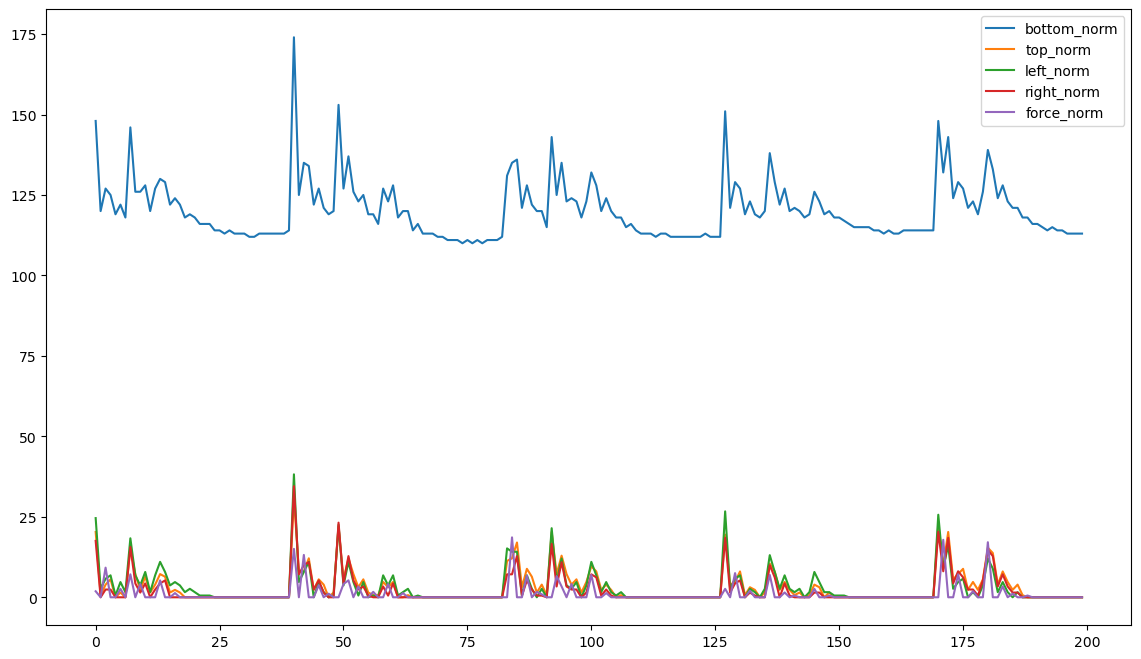

In [79]:
fig, ax = plt.subplots(figsize=(14, 8))  # Adjust the size as needed
slice_range = slice(4000, 4200)

s[s < 5] = 0

ax.plot(df_iu['bottom_clipped'].values[slice_range], label='bottom_norm')
ax.plot(df_iu['top_clipped'].values[slice_range], label='top_norm')
ax.plot(df_iu['left_clipped'].values[slice_range], label='left_norm')
ax.plot(df_iu['right_clipped'].values[slice_range], label='right_norm')
ax.plot(df_iu['force_clipped'].values[slice_range], label='force_norm')

ax.legend()  # Show legend

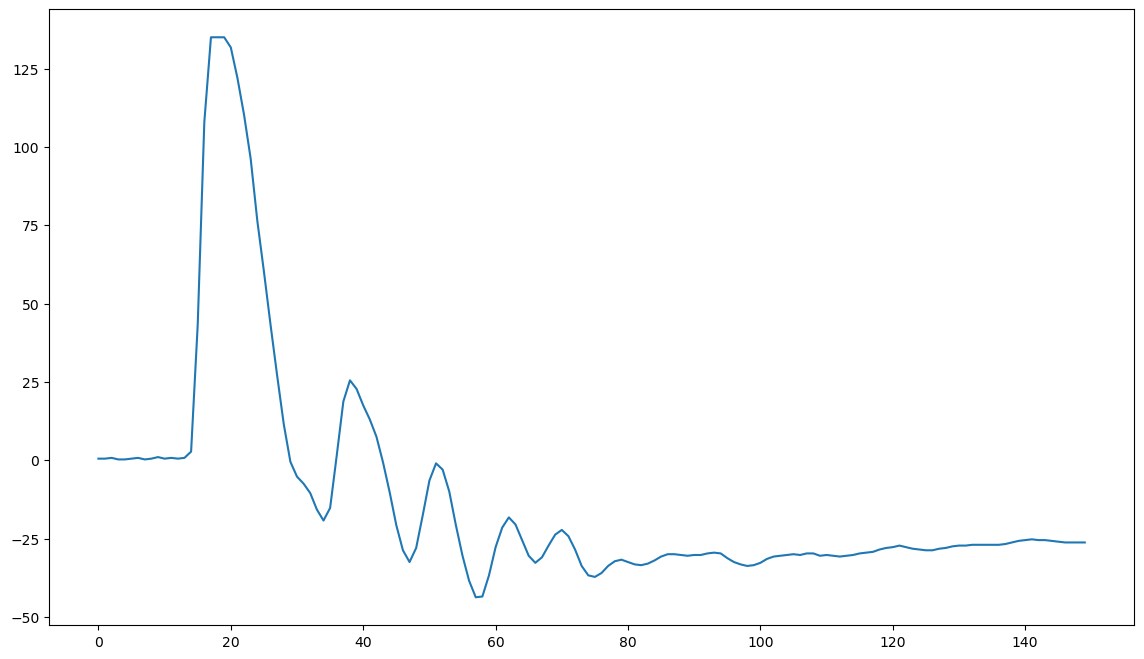

In [411]:
fig, ax = plt.subplots(figsize=(14, 8))  # Adjust the size as needed
ax.plot(impulse)

In [58]:
def butter_lowpass(cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = lfilter(b, a, data)
    return y

In [65]:
filtered_signal = lowpass_filter((df_iu[l]-gmean).values, 25, 100, order=6)
#filtered_signal = highpass_filter(filtered_signal, 1, 100)
#filtered_signal = np.diff(filtered_signal)

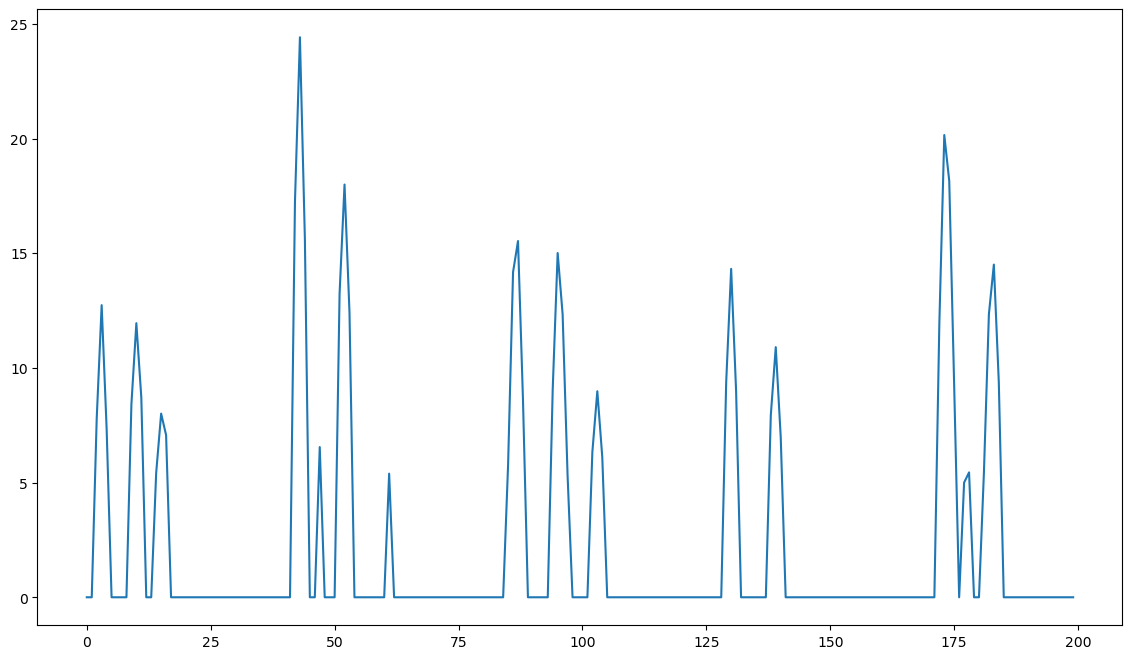

In [66]:
fig, ax = plt.subplots(figsize=(14, 8))  # Adjust the size as needed
#ax.plot(filtered_signal, color='blue')
s = filtered_signal.copy()
s[s < 5] = 0
ax.plot(s[slice_range])
#ax.plot(np.diff(s[3300:3500]))


In [439]:
1/2e-3

500.0

In [471]:
def detect_peaks(signal, threshold=0):
    peaks = []
    n = len(signal)

    for i in range(1, n - 1):  # Avoid the first and last points
        # Check if the current point is greater than its neighbors
        if signal[i] > signal[i - 1] and signal[i] > signal[i + 1]:
            # Check if the peak is above the threshold
            if signal[i] > threshold:
                peaks.append(signal[i])
            else:
                peaks.append(0)
        else:
            peaks.append(0)

    return peaks


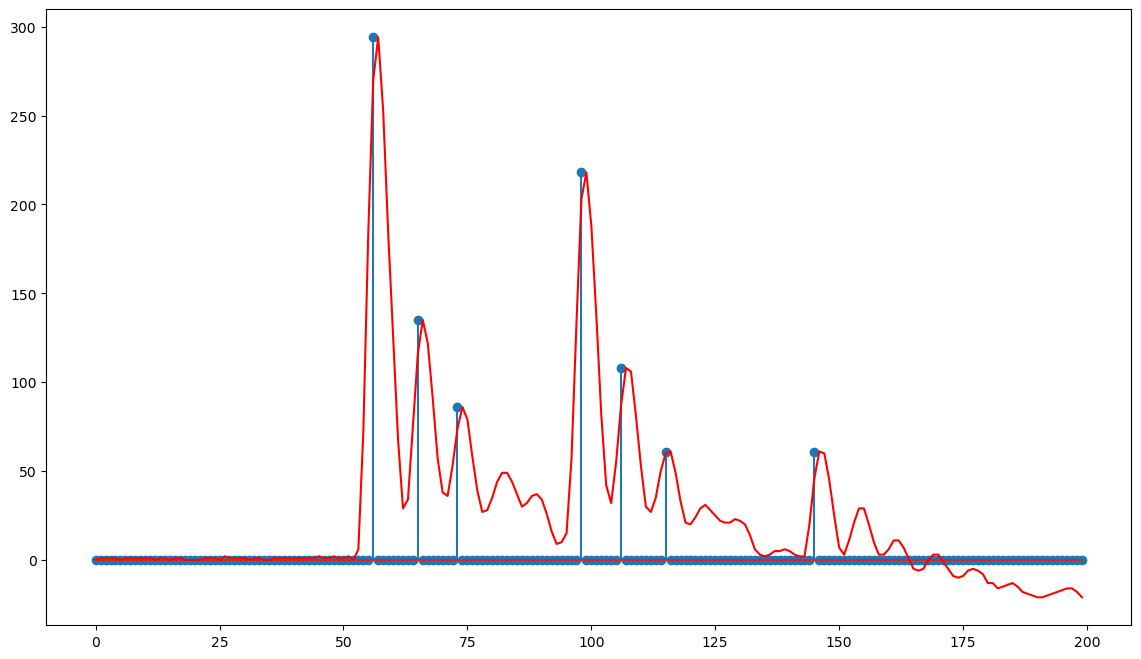

In [481]:
peaks = detect_peaks(signal, threshold=50)

fig, ax = plt.subplots(figsize=(14, 8))  # Adjust the size as needed
ax.stem(peaks[10300:10500])
ax.plot(signal[10300:10500], color='red')

In [81]:
for i in range (30, 256):
    print(f"bpm:{i}, microseconds: {60000000/i}")

bpm:30, microseconds: 2000000.0
bpm:31, microseconds: 1935483.8709677418
bpm:32, microseconds: 1875000.0
bpm:33, microseconds: 1818181.8181818181
bpm:34, microseconds: 1764705.8823529412
bpm:35, microseconds: 1714285.7142857143
bpm:36, microseconds: 1666666.6666666667
bpm:37, microseconds: 1621621.6216216215
bpm:38, microseconds: 1578947.3684210526
bpm:39, microseconds: 1538461.5384615385
bpm:40, microseconds: 1500000.0
bpm:41, microseconds: 1463414.6341463414
bpm:42, microseconds: 1428571.4285714286
bpm:43, microseconds: 1395348.8372093022
bpm:44, microseconds: 1363636.3636363635
bpm:45, microseconds: 1333333.3333333333
bpm:46, microseconds: 1304347.8260869565
bpm:47, microseconds: 1276595.744680851
bpm:48, microseconds: 1250000.0
bpm:49, microseconds: 1224489.7959183673
bpm:50, microseconds: 1200000.0
bpm:51, microseconds: 1176470.5882352942
bpm:52, microseconds: 1153846.1538461538
bpm:53, microseconds: 1132075.4716981133
bpm:54, microseconds: 1111111.111111111
bpm:55, microseconds: 